# Network Establishment and Social Network Analysis
# Extract the Backbone
This analysis applied the same disparity filtering algorithm (alpha = 0.3) used in Layer 1 to construct the initial network backbone. It then removed connections that overlap with the adversarial network. 

In [2]:
import pandas as pd
import networkx as nx
import netbone as nb
from netbone.filters import threshold_filter
import random
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

# Compatibility patch: some matplotlib_inline versions still access rcParams._get.
if not hasattr(matplotlib.rcParams, "_get"):
    type(matplotlib.rcParams)._get = lambda self, key: self[key]

random.seed(42)
np.random.seed(42)

Can't load ECM Model in windows, try using it on linux


In [4]:
pair_similarities = pd.read_csv('../data/layer2/semantic_network_edges.csv')

In [17]:
df_input = pair_similarities.rename(columns={'Source': 'source', 'Target': 'target','Weight':'weight'})
df_with_alpha = nb.disparity(df_input, weight='weight')

backbone_similarity = threshold_filter(df_with_alpha, 0.3)

assert backbone_similarity
backbone_similarity_df = nx.to_pandas_edgelist(backbone_similarity)

backbone_similarity_df.to_csv('../data/layer2/layer2_backbone.csv', encoding='utf-8', index=False)

Disparity Filter


In [18]:
# remove adversarial edges from similarity backbone edges

def _detect_edge_columns(df: pd.DataFrame):
    src_candidates = ["s1", "source"]
    tgt_candidates = ["s2", "target"]

    src_col = next((c for c in src_candidates if c in df.columns), None)
    tgt_col = next((c for c in tgt_candidates if c in df.columns), None)

    if src_col is None or tgt_col is None:
        raise ValueError(
            "Cannot detect edge columns. Expected source/target or Source/Target.")

    return src_col, tgt_col


def remove_edges_by_table(base_edges: pd.DataFrame, edges_to_remove: pd.DataFrame, undirected: bool = True):
    base_src, base_tgt = _detect_edge_columns(base_edges)
    rm_src, rm_tgt = _detect_edge_columns(edges_to_remove)

    base = base_edges.copy()
    rm = edges_to_remove.copy()

    # Build comparable edge keys without changing original columns.
    b_s = base[base_src].astype(str)
    b_t = base[base_tgt].astype(str)
    r_s = rm[rm_src].astype(str)
    r_t = rm[rm_tgt].astype(str)

    if undirected:
        base["_u"] = b_s.where(b_s <= b_t, b_t)
        base["_v"] = b_t.where(b_s <= b_t, b_s)
        rm["_u"] = r_s.where(r_s <= r_t, r_t)
        rm["_v"] = r_t.where(r_s <= r_t, r_s)
    else:
        base["_u"], base["_v"] = b_s, b_t
        rm["_u"], rm["_v"] = r_s, r_t

    merged = base.merge(
        rm[["_u", "_v"]].drop_duplicates(),
        on=["_u", "_v"],
        how="left",
        indicator=True,
    )

    result = merged.loc[merged["_merge"] ==
                        "left_only", base_edges.columns].copy()
    return result


base_edges = pd.read_csv("../data/layer2/layer2_backbone.csv")
edges_to_remove = pd.read_csv("../data/layer1/layer1_backbone_neg.csv")

filtered_edges = remove_edges_by_table(
    base_edges, edges_to_remove, undirected=True)

print(f"Before: {len(base_edges)} edges")
print(f"Removed: {len(base_edges) - len(filtered_edges)} edges")
print(f"After: {len(filtered_edges)} edges")

filtered_edges.to_csv(
    "../data/layer2/layer2_backbone_filtered.csv", index=False, encoding="utf-8")

Before: 2333 edges
Removed: 62 edges
After: 2271 edges


# Basic Inspection
The co-semantic layer contains 179 states and 2,271 edges. Between each pair of states, their average issue similarity has reached 0.9551 on a scale from 0 to 1, indicating a high commonality shared across all states.

In [4]:
# info
df = pd.read_csv('../data/layer2/layer2_backbone_filtered.csv')

G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
total_weight = sum([d['weight'] for u, v, d in G.edges(data=True)])
avg_weight = total_weight/num_edges

# weighted degree (strength) average
weighted_degrees = [G.degree(n, weight='weight') for n in G.nodes()]
avg_weighted_degree = sum(weighted_degrees) / num_nodes

print(f"Nodes: {num_nodes}")
print(f"Edges: {num_edges}")
print(f"Strength: {total_weight:.4f}")
print(f"Average edge weight: {avg_weight:.4f}")
print(f"Average weighted degree (strength): {avg_weighted_degree:.4f}")


Nodes: 179
Edges: 2271
Strength: 2169.0585
Average edge weight: 0.9551
Average weighted degree (strength): 24.2353


# Network Assessment
The common issue layer contains 179 states and 2,271 edges. Between each state pair, the average issue similarity reaches 0.955 on a scale from 0 to 1, indicating a high degree of issue commonality across states. Compared to the positive interaction layer, both density (D = 0.143) and transitivity (T_obs = 0.794, T_exp = 0.206, p < 0.001) are markedly higher in the common issue layer. However, it still reflects a similar pattern that only a few states share highly similar issues, with such similarities tending to cluster among neighbors, which can be conceptualized as the classical RSCT (Regional Security Complex Theory; Buzan & Wæver, 2003). It defines a complex where states’ primary security concerns are sufficiently interlinked to distinguish them from surrounding states. Consequently, security interactions are more likely to appear within complexes rather than across them. In doing so, the theory offers a valuable regional-level aspect on the political landscape, in contrast to globalization trends. Efficiency is also higher in this layer, with a mean distance of 3.589, (MD_exp = 2.091, p<0.001), a diameter of 10 (Dia_exp = 4.309, p<0.001), and a global efficiency of 0.243 (G_exp = 0.527, p<0.001). However, compared to configuration models, efficiency remains relatively low, reflecting the diversity and regionalization of issues across states. More specifically, states are not united by shared global issues; instead, they are more preoccupied with regional conflicts or issues. The localization of issues, on one hand, leads to a more stable structure in which disruptions remain locally contained. On the other hand, it also limits opportunities for states to form alliances with those facing different regional issues. 

In [5]:
def network_measures(G):
    density = nx.density(G)
    transitivity = nx.transitivity(G)
    # in case that the shortest path is infinite if the network is not connected
    if nx.is_connected(G):
        mean_distance = nx.average_shortest_path_length(G)
        diameter = nx.diameter(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        mean_distance = nx.average_shortest_path_length(subgraph)
        diameter = nx.diameter(subgraph)
    global_eff = nx.global_efficiency(G)
    return density, transitivity, mean_distance, diameter, global_eff

metrics = network_measures(G)
print(f"Density: {metrics[0]:.3f}")
print(f"Transitivity: {metrics[1]:.3f}")
print(f"Mean Distance: {metrics[2]:.3f}")
print(f"Diameter: {metrics[3]}")
print(f"Global Efficiency: {metrics[4]:.3f}")

Density: 0.143
Transitivity: 0.794
Mean Distance: 3.589
Diameter: 10
Global Efficiency: 0.387


In [6]:
def config_permutation_network_measures(G, n_perm=1000):
    degree_seq = [d for n, d in G.degree()]
    results = {'density': [], 'transitivity': [], 'mean_distance': [], 'diameter': [], 'global_efficiency': []}
    for _ in range(n_perm):
        # Configuration model
        G_conf = nx.configuration_model(degree_seq)
        G_conf = nx.Graph(G_conf)
        G_conf.remove_edges_from(nx.selfloop_edges(G_conf))
        density, transitivity, mean_distance, diameter, global_eff = network_measures(G_conf)
        results['density'].append(density)
        results['transitivity'].append(transitivity)
        results['mean_distance'].append(mean_distance)
        results['diameter'].append(diameter)
        results['global_efficiency'].append(global_eff)
    for k in results:
        results[k] = np.array(results[k]) # type:ignore
    return results

config_results = config_permutation_network_measures(G, n_perm=1000)

obs_density, obs_trans, obs_mean_dist, obs_diam, obs_eff = network_measures(G)

p_density = (np.sum(config_results['density'] >= obs_density) + 1) / (len(config_results['density']) + 1)
p_trans = (np.sum(config_results['transitivity'] >= obs_trans) + 1) / (len(config_results['transitivity']) + 1) # type:ignore
p_mean_dist = (np.sum(config_results['mean_distance'] >= obs_mean_dist) + 1) / (len(config_results['mean_distance']) + 1) # type:ignore
p_diam = (np.sum(config_results['diameter'] >= obs_diam) + 1) / (len(config_results['diameter']) + 1) # type:ignore
p_eff = (np.sum(config_results['global_efficiency'] <= obs_eff) + 1) / (len(config_results['global_efficiency']) + 1) # type:ignore

print(f'Density p-value: {p_density:.3f}')
print(f'Transitivity p-value: {p_trans:.3f}')
print(f'Mean distance p-value: {p_mean_dist:.3f}')
print(f'Diameter p-value: {p_diam:.3f}')
print(f'Global efficiency p-value: {p_eff:.3f}')


Density p-value: 0.001
Transitivity p-value: 0.001
Mean distance p-value: 0.001
Diameter p-value: 0.001
Global efficiency p-value: 0.001


In [24]:
print(f'Density permutation mean: {config_results["density"].mean():.3f}') # type:ignore
print(f'Transitivity permutation mean: {config_results["transitivity"].mean():.3f}') # type:ignore
print(f'Mean_distance permutation mean: {config_results["mean_distance"].mean():.3f}') # type:ignore
print(f'Diameter permutation mean: {config_results["diameter"].mean():.3f}') # type:ignore
print(f'Global_efficiency permutation mean: {config_results["global_efficiency"].mean():.3f}') # type:ignore

Density permutation mean: 0.126
Transitivity permutation mean: 0.206
Mean_distance permutation mean: 2.091
Diameter permutation mean: 4.309
Global_efficiency permutation mean: 0.527


# Community Detection
In this layer, six communities (Appendix C) were identified with a total modularity of 0.621, also suggesting a well-defined community structure with higher density (Figure 4) and similarities within communities (Figure 5). The global EI Index of -0.881 suggests an extremely high degree of issue insularity, with individual community indices ranging from -0.936 to 0.115. The regionalization phenomenon further supports the RSCT. However, the original theory relies on geographical proximity to set boundaries for complexes, a criterion not strictly observed in the communities detected in this layer. For example, states such as Austria and Kazakhstan are assigned into the same community, owing to the introduction of non-territory issues and global calculation of issue similarities. Therefore, this study extends RSCT beyond its original geographical boundaries, suggesting that issue-based similarities can transcend territorial proximity in defining security complexes.

In [7]:
communities = nx.community.louvain_communities(G, weight='weight', seed=42)
partition = {}
for i, comm in enumerate(communities):
    for node in comm:
        partition[node] = i
modularity = nx.community.modularity(G, communities, weight='weight')

print(f"Detected communities: {len(communities)}")
print(f"Weighted modularity: {modularity:.3f}")

Detected communities: 6
Weighted modularity: 0.621


In [26]:
def calculate_weighted_ei(G, partition):
    total_w_internal = 0
    total_w_external = 0
    
    community_ids = sorted(list(set(partition.values())))
    comm_stats = {cid: {'I_w': 0, 'E_w': 0} for cid in community_ids}

    for u, v, d in G.edges(data=True):
        weight = d.get('weight', 1.0)
        comm_u = partition[u]
        comm_v = partition[v]
        
        if comm_u == comm_v:
            total_w_internal += weight
            comm_stats[comm_u]['I_w'] += weight
        else:
            total_w_external += weight
            comm_stats[comm_u]['E_w'] += weight
            comm_stats[comm_v]['E_w'] += weight

    # (E - I) / (E + I)
    global_weighted_ei = (total_w_external - total_w_internal) / (total_w_external + total_w_internal)
    
    details = []
    for cid in community_ids:
        Iw = comm_stats[cid]['I_w']
        Ew = comm_stats[cid]['E_w']
        ei_local = (Ew - Iw) / (Ew + Iw) if (Ew + Iw) > 0 else 0
        comm_size = list(partition.values()).count(cid)
        details.append({
            'Community': f"Comm {cid}",
            'Size':comm_size,
            'Internal_Weight_Sum': Iw,
            'External_Weight_Sum': Ew,
            'Weighted_EI': ei_local
        })

    df_details = pd.DataFrame(details)
    
    print(f"=== Global Weighted E-I Analysis ===")
    print(f"Total Internal Weight (I): {total_w_internal:.3f}")
    print(f"Total External Weight (E): {total_w_external:.3f}")
    print(f"Global Weighted E-I Index: {global_weighted_ei:.3f}")
    print("=====================================")
    
    return global_weighted_ei, df_details

global_wei, df_wei = calculate_weighted_ei(G, partition)
print(df_wei)

=== Global Weighted E-I Analysis ===
Total Internal Weight (I): 2040.300
Total External Weight (E): 128.759
Global Weighted E-I Index: -0.881
  Community  Size  Internal_Weight_Sum  External_Weight_Sum  Weighted_EI
0    Comm 0    35           351.297716            95.083304    -0.573981
1    Comm 1    39           158.459847            36.501589    -0.625551
2    Comm 2     2             0.979935             0.819521    -0.089145
3    Comm 3    43           560.014828            82.184353    -0.744053
4    Comm 4    10             9.023780            11.367304     0.114929
5    Comm 5    50           960.523579            31.561519    -0.936373


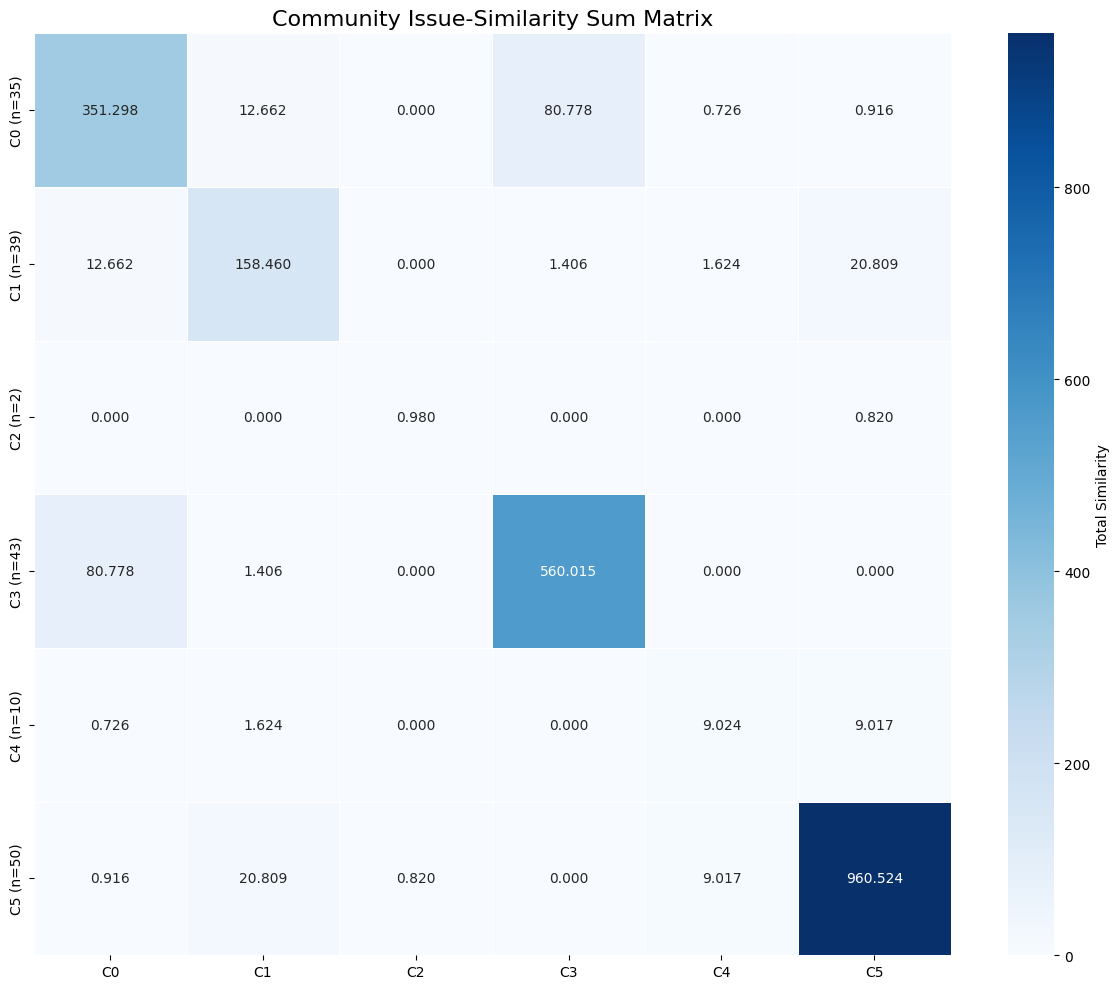

In [30]:
def plot_community_interaction_heatmap(G, partition):
    community_ids = sorted(list(set(partition.values())))
    num_communities = len(community_ids)
    comm_sizes = {cid: list(partition.values()).count(cid) for cid in community_ids}
    
    interaction_matrix = np.zeros((num_communities, num_communities))
    
    for u, v, d in G.edges(data=True):
        weight = d.get('weight', 1.0)
        comm_u = partition[u]
        comm_v = partition[v]
        
        interaction_matrix[comm_u][comm_v] += weight
        if comm_u != comm_v:
            interaction_matrix[comm_v][comm_u] += weight
            
    df_matrix = pd.DataFrame(
        interaction_matrix, 
        index=[f'C{i} (n={comm_sizes[i]})' for i in community_ids],
        columns=[f'C{i}' for i in community_ids]
    )
    
    plt.figure(figsize=(12, 10))
    
    sns.heatmap(df_matrix, annot=True, fmt='.3f', cmap='Blues', 
                linewidths=.5, cbar_kws={'label': 'Total Similarity'})
    
    plt.title("Community Issue-Similarity Sum Matrix", fontsize=16)
    # plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_community_interaction_heatmap(G, partition)

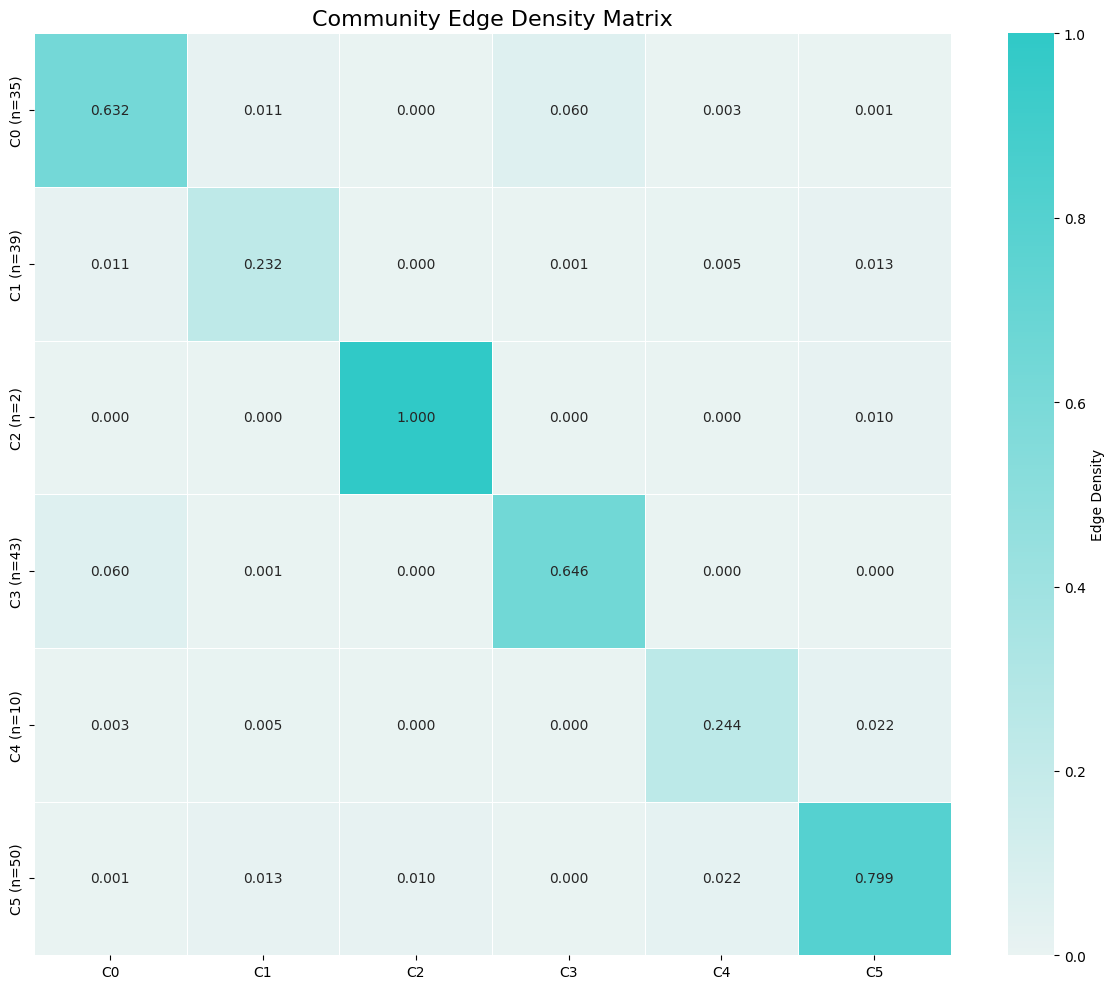

In [9]:
def plot_community_density_heatmap(G, partition):
    community_ids = sorted(list(set(partition.values())))
    num_communities = len(community_ids)
    comm_sizes = {cid: list(partition.values()).count(cid) for cid in community_ids}
    
    edge_count_matrix = np.zeros((num_communities, num_communities))
    for u, v in G.edges():
        comm_u = partition[u]
        comm_v = partition[v]
        
        edge_count_matrix[comm_u][comm_v] += 1
        if comm_u != comm_v:
            edge_count_matrix[comm_v][comm_u] += 1
            
    density_matrix = np.zeros((num_communities, num_communities))
    for i in range(num_communities):
        for j in range(num_communities):
            s_i = comm_sizes[community_ids[i]]
            s_j = comm_sizes[community_ids[j]]
            
            if i == j:
                possible = s_i * (s_i - 1) / 2 if s_i > 1 else 1
            else:
                possible = s_i * s_j
            
            density_matrix[i][j] = edge_count_matrix[i][j] / possible

    df_density = pd.DataFrame(
        density_matrix, 
        index=[f'C{i} (n={comm_sizes[i]})' for i in community_ids],
        columns=[f'C{i}' for i in community_ids]
    )
    
    plt.figure(figsize=(12, 10))
    custom_palette = sns.light_palette("#30c9c7", as_cmap=True)
    sns.heatmap(df_density, annot=True, fmt='.3f', cmap=custom_palette, 
                linewidths=.5, cbar_kws={'label': 'Edge Density'})
    
    plt.title("Community Edge Density Matrix", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_community_density_heatmap(G, partition)

In [32]:
# print node labels in each community
community_to_nodes = {}
for node, cid in partition.items():
    community_to_nodes.setdefault(cid, []).append(node)

for cid in sorted(community_to_nodes.keys()):
    labels = sorted(community_to_nodes[cid])
    print(f"Community {cid} (n={len(labels)}):")
    print(", ".join(labels))
    print("-" * 60)

Community 0 (n=35):
Algeria, Andorra, Azerbaijan, Bahrain, Chad, Cyprus, Egypt, Ethiopia, Greece, Iran, Iraq, Israel, Jordan, Kuwait, Lebanon, Liberia, Luxembourg, Malta, Monaco, Oman, Palestine, Qatar, San Marino, Saudi Arabia, Senegal, Somalia, South Sudan, Sudan, Syria, Tunisia, Türkiye, United Arab Emirates, Uzbekistan, Vanuatu, Yemen
------------------------------------------------------------
Community 1 (n=39):
Afghanistan, Bahamas, Barbados, Bhutan, Brunei Darussalam, Cambodia, China, Cuba, Dominican Republic, Fiji, India, Indonesia, Jamaica, Japan, Kiribati, Laos, Madagascar, Malaysia, Mongolia, Myanmar, Nepal, New Zealand, North Korea, Pakistan, Palau, Papua New Guinea, Philippines, Singapore, Solomon Islands, South Korea, Spain, Sri Lanka, St. Vincent and the Grenadines, Thailand, Timor-Leste, Tonga, Tuvalu, Vietnam, Zimbabwe
------------------------------------------------------------
Community 2 (n=2):
Cabo Verde, Canada
----------------------------------------------------

# Node Identification
At the actor level, in contrast to the monopolizing pattern observed in the positive interaction layer, different states occupy prominent positions within the common issue layer. More importantly, these states are often absent from political research. For example, Grenada possesses the highest degree and eigenvector centrality, suggesting that it is most extensively and influentially connected through shared issues within the network. Portugal possesses the highest betweenness centrality, functioning as a broker bridging issue similarities across states. Regarding closeness, Jamaica ranks highest, indicating that it is most efficiently connected to all other states through shared issues. In other words, Jamaica may not directly share issues with the most states, but it reaches all other states most efficiently through indirect similarity paths.

In [11]:
# centrality: top 10 nodes for each metric
degree_c = nx.degree_centrality(G)
betweenness_c = nx.betweenness_centrality(G)
closeness_c = nx.closeness_centrality(G)

try:
    eigenvector_c = nx.eigenvector_centrality(G, max_iter=5000)
except nx.PowerIterationFailedConvergence:
    eigenvector_c = nx.eigenvector_centrality_numpy(G)


def print_top10(metric_name, metric_dict):
    top10 = sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"\n=== Top 10 by {metric_name} ===")
    for rank, (node, score) in enumerate(top10, start=1):
        print(f"{rank:>2}. {node:<25} {score:.3f}")

print_top10("Degree Centrality", degree_c)
print_top10("Betweenness Centrality", betweenness_c)
print_top10("Closeness Centrality", closeness_c)
print_top10("Eigenvector Centrality", eigenvector_c)


=== Top 10 by Degree Centrality ===
 1. Grenada                   0.292
 2. Ecuador                   0.287
 3. Guinea-Bissau             0.270
 4. Malawi                    0.270
 5. Cameroon                  0.270
 6. Suriname                  0.270
 7. Antigua and Barbuda       0.270
 8. Equatorial Guinea         0.270
 9. Eswatini                  0.270
10. Dominica                  0.270

=== Top 10 by Betweenness Centrality ===
 1. Portugal                  0.157
 2. Sao Tome and Principe     0.132
 3. Jamaica                   0.127
 4. Bahamas                   0.100
 5. Uzbekistan                0.086
 6. Greece                    0.076
 7. Vanuatu                   0.075
 8. Ecuador                   0.071
 9. Grenada                   0.071
10. Philippines               0.071

=== Top 10 by Closeness Centrality ===
 1. Jamaica                   0.382
 2. Bahamas                   0.381
 3. Jordan                    0.364
 4. Lebanon                   0.363
 5. Oman         